# Arm 1 (`go_enrichment` v1) — full-dataset result

**Arm 1 is the no-LLM baseline**: a classical statistical test (following the method of the established
tool g:Profiler) that checks, for a gene's set of reliably-expressed cell types, which biological-process
GO terms are over-represented among them. No language model is involved anywhere in this arm — it is pure
statistics, run here across every one of the dataset's ~15,900 scoreable genes.

**Headline result, stated plainly up front:** of the GO terms this method flags as statistically
significant, **94% do not match the gene's own, independently-known GO annotation at all.** Only
**7.7% of genes** get even one real match, and only **1.2%** get an exact one. This notebook shows that
result from several angles and, in the last section, why it happens — the method is not broken, but it is
structurally limited to a narrow slice of genes (see `approaches/README.md` for the full methodology and
the earlier ceiling analysis this notebook's last plot draws on).

Every number plotted below is recomputed from the saved result files in this notebook, not hand-typed, so
it cannot silently drift from the underlying data.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.05)

# ---- ONE color code, reused in every plot below -----------------------------------------------
# Two separate palettes on purpose: a prediction's "outcome" (exact/upward/downward/no_match) is a
# different kind of thing from a plain count/volume, so they get visually distinct color families —
# this way a reader never mistakes a volume bar for an outcome-category bar.
COLORS = {
    # match-outcome palette (colorblind-safe, Okabe-Ito based)
    "exact":    "#009E73",  # green  -- the predicted term IS one of the gene's own annotated terms
    "upward":   "#0072B2",  # blue   -- the predicted term is a more GENERAL version of a true term
                            #           (reached by walking UP the GO graph from the true term)
    "downward": "#E69F00",  # orange -- the predicted term is a more SPECIFIC version of a true term
                            #           (reached by walking UP the GO graph from the prediction)
    "no_match": "#7F7F7F",  # grey   -- neither of the above: no informative relation found
    # plain volume/count palette -- used only for plots that are NOT about match outcome
    "volume":   "#4C72B0",  # single neutral blue, never reused for an outcome category
}
ORDER = ["exact", "upward", "downward", "no_match"]  # fixed left-to-right / top-to-bottom order everywhere

def save(fig, name: str) -> None:
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## Loading the results

- **`match_summary__go_enrichment_v1_positive__all.json`** — produced by `scripts/summarize_go_matches.py`
  on the full arm-1 run. For every gene, it classifies each of the gene's *significant* GO-term predictions
  (g:SCS-corrected p < 0.05 — the same significance threshold g:Profiler itself defaults to) against that
  gene's own, independently-known GO annotation:
    - **exact** — the predicted term literally IS one of the gene's annotated terms
    - **upward (generalisation)** — reached by walking UP the GO graph from a true term to the prediction
      (the prediction is a broader category that contains the truth, e.g. "phagocytosis, engulfment" (true)
      → "phagocytosis" (predicted), 1 step up)
    - **downward (specialisation)** — the reverse: walking up FROM the prediction reaches a true term (the
      prediction is a plausible, more specific guess that happens not to be separately annotated)
    - **no_match** — neither: no informative relation between the prediction and the truth
- **`go_ceiling_genes.tsv`** — a separate, earlier analysis: for each gene, the best score *any* method
  could possibly achieve using only this candidate-term vocabulary (`f1_top1`, the "oracle ceiling") and
  what a method would score by picking a term at random (`f1_top1_random`, the floor). Used only in the
  last plot, to explain *why* the result above looks the way it does.

In [2]:
RESULTS_DIR = ROOT / "data" / "go_experiment" / "match_summaries"
summary = json.loads((RESULTS_DIR / "match_summary__go_enrichment_v1_positive__all.json").read_text())

genes = pd.DataFrame(summary["per_gene"])
# sanity check: every gene's four outcome counts must add up to its own n_significant
assert (genes[["n_exact", "n_upward", "n_downward", "n_no_match"]].sum(axis=1) == genes["n_significant"]).all()

print(f"genes with a result:        {len(genes):,}")
print(f"significance threshold:     {summary['significance_basis']}")
print(f"total significant terms:    {summary['terms']['n_total']:,}")

genes with a result:        15,754
significance threshold:     p_gscs < 0.05 (g:SCS)
total significant terms:    26,779


## 1. Where does the gene population go? (funnel)

The most direct view of the attrition: starting from every gene that *could* be scored, how many make it
through each successive, stricter bar — getting any significant prediction at all, then getting a real
match, then getting an exact one. Nothing is hidden or reordered to look better; the bars simply shrink by
however much they shrink.

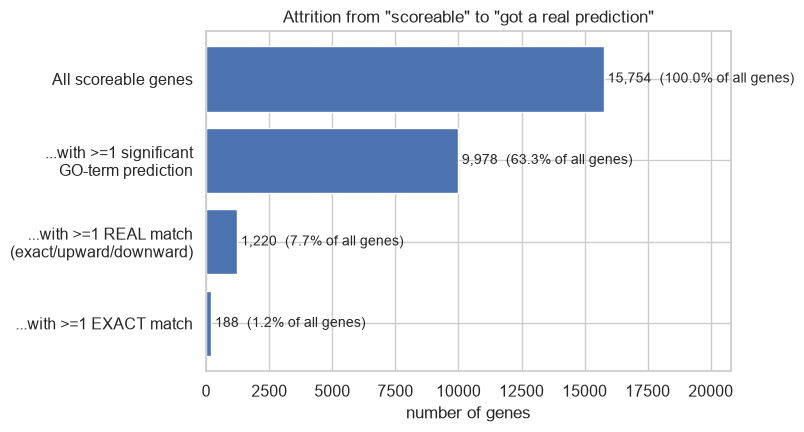

In [3]:
n_total = len(genes)
n_any_sig = (genes["n_significant"] > 0).sum()
n_any_match = ((genes["n_exact"] + genes["n_upward"] + genes["n_downward"]) > 0).sum()
n_any_exact = (genes["n_exact"] > 0).sum()

funnel = pd.Series(
    {
        "All scoreable genes": n_total,
        "...with >=1 significant\nGO-term prediction": n_any_sig,
        "...with >=1 REAL match\n(exact/upward/downward)": n_any_match,
        "...with >=1 EXACT match": n_any_exact,
    }
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(funnel.index[::-1], funnel.values[::-1], color=COLORS["volume"])
for bar, v in zip(bars, funnel.values[::-1]):
    ax.text(bar.get_width() + n_total * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({v / n_total:.1%} of all genes)", va="center", fontsize=10)
ax.set_xlim(0, n_total * 1.32)
ax.set_xlabel("number of genes")
ax.set_title("Attrition from \"scoreable\" to \"got a real prediction\"")
fig.tight_layout()
save(fig, "01_funnel")
plt.show()

## 2. What happens to a significant term, once produced? (outcome breakdown)

This is a bar chart, **deliberately not a pie chart and not log-scaled**. A pie chart makes it genuinely
harder to read off precise shares when one slice is this dominant, and a log scale would visually compress
the very dominance this plot needs to show honestly — the point of this figure is specifically that
`no_match` is overwhelming, and a transform that shrinks that visual gap would misrepresent the result.

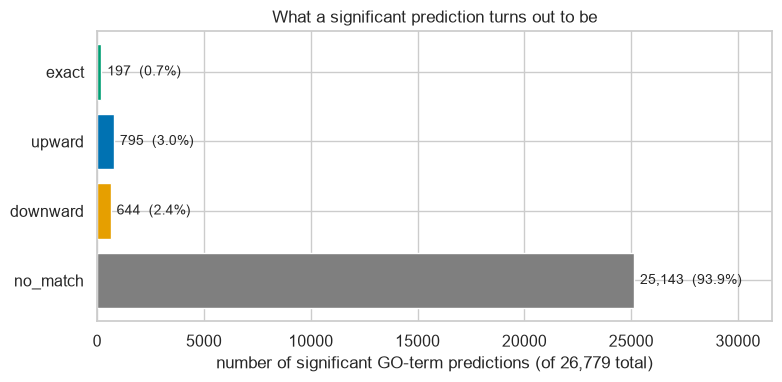

In [4]:
t = summary["terms"]
# field names in the summary JSON: n_exact, n_upward_total, n_downward_total, n_no_match
counts = pd.Series({"exact": t["n_exact"], "upward": t["n_upward_total"],
                    "downward": t["n_downward_total"], "no_match": t["n_no_match"]})[ORDER]
total_terms = counts.sum()
assert total_terms == t["n_total"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=[COLORS[k] for k in ORDER[::-1]])
for bar, v in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + total_terms * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({v / total_terms:.1%})", va="center", fontsize=10)
ax.set_xlim(0, total_terms * 1.18)
ax.set_xlabel(f"number of significant GO-term predictions (of {total_terms:,} total)")
ax.set_title("What a significant prediction turns out to be")
fig.tight_layout()
save(fig, "02_outcome_breakdown")
plt.show()

## 3. Among the real matches, how close are they?

Even the matches that aren't exact come in different strengths: a 1-step relation (e.g. a direct parent
term) is a close, specific match; a 5+ step relation is a very loose, barely-informative one. Same blue
(upward) / orange (downward) as the previous plot, so the connection to the "upward"/"downward" slices
above is visually immediate.

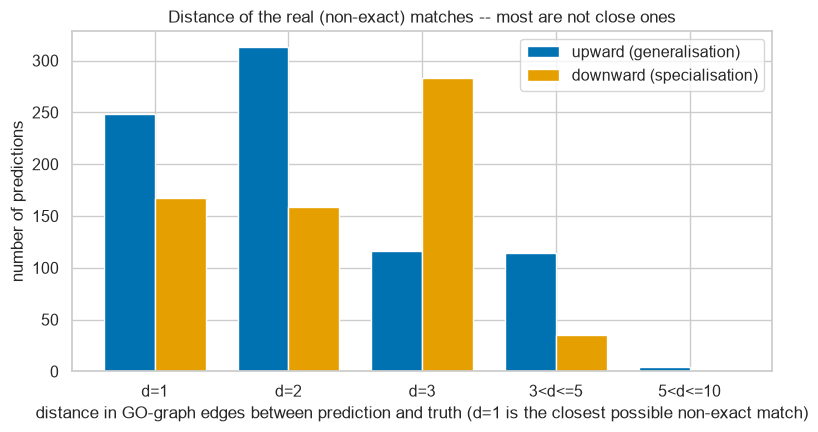

In [5]:
edges = summary["bin_edges"]  # upper bound of each non-exact distance bin, e.g. [1, 2, 3, 5, 10]
bin_labels = [f"d={edges[0]}"] + (
    [f"d={e}" if edges[i] - edges[i - 1] <= 1 else f"{edges[i-1]}<d<={e}" for i, e in enumerate(edges[1:], 1)]
)
up = summary["terms"]["upward_bins"]
down = summary["terms"]["downward_bins"]
dist = pd.DataFrame({"upward": [up.get(b, 0) for b in bin_labels],
                     "downward": [down.get(b, 0) for b in bin_labels]}, index=bin_labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(dist))
w = 0.38
ax.bar([i - w / 2 for i in x], dist["upward"], width=w, color=COLORS["upward"], label="upward (generalisation)")
ax.bar([i + w / 2 for i in x], dist["downward"], width=w, color=COLORS["downward"], label="downward (specialisation)")
ax.set_xticks(list(x)); ax.set_xticklabels(dist.index)
ax.set_xlabel("distance in GO-graph edges between prediction and truth (d=1 is the closest possible non-exact match)")
ax.set_ylabel("number of predictions")
ax.set_title("Distance of the real (non-exact) matches -- most are not close ones")
ax.legend()
fig.tight_layout()
save(fig, "03_match_distance")
plt.show()

## 4. How many significant terms does a typical gene even get?

The 37% "zero significant terms" headline from the funnel is the extreme left bar of a much broader
distribution -- shown here in full so it isn't read as an isolated, cherry-picked statistic.

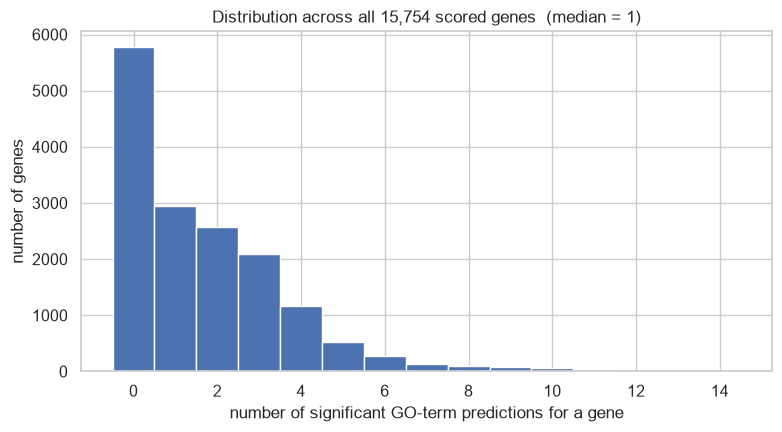

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
max_n = int(genes["n_significant"].max())
ax.hist(genes["n_significant"], bins=range(0, max_n + 2), align="left",
        color=COLORS["volume"], edgecolor="white")
ax.set_xlabel("number of significant GO-term predictions for a gene")
ax.set_ylabel("number of genes")
ax.set_title(f"Distribution across all {len(genes):,} scored genes  (median = {int(genes['n_significant'].median())})")
ax.set_xticks(range(0, max_n + 1, 2))
fig.tight_layout()
save(fig, "04_n_significant_distribution")
plt.show()

## 5. Is this a structural limitation, or arbitrary noise?

A separate, earlier analysis computed, for every gene, the **oracle ceiling**: the best possible score
*any* method could achieve using only this candidate vocabulary of GO terms (not what arm 1 achieved --
the theoretical best case). If genes that got a real match tend to have a *higher* ceiling than genes that
didn't, that confirms the result above is explained by a known, structural limit on what this vocabulary
can express for a given gene -- not by the method behaving arbitrarily.

genes with both a match result and a ceiling score: 15,754 / 15,754


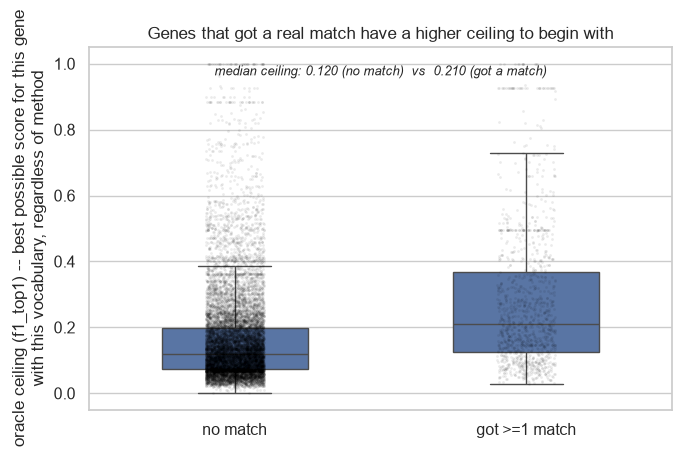

In [7]:
ceiling = pd.read_csv(ROOT / "data" / "go_ceiling_genes.tsv", sep="\t")
merged = genes.merge(ceiling, left_on="gene_id", right_on="ensembl_id", how="inner")
print(f"genes with both a match result and a ceiling score: {len(merged):,} / {len(genes):,}")

merged["got_a_match"] = ((merged["n_exact"] + merged["n_upward"] + merged["n_downward"]) > 0)
merged["group"] = merged["got_a_match"].map({True: "got >=1 match", False: "no match"})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=merged, x="group", y="f1_top1", order=["no match", "got >=1 match"],
            color=COLORS["volume"], width=0.5, ax=ax, showfliers=False)
sns.stripplot(data=merged, x="group", y="f1_top1", order=["no match", "got >=1 match"],
             color="black", alpha=0.08, size=2, ax=ax)
ax.set_ylabel("oracle ceiling (f1_top1) -- best possible score for this gene\nwith this vocabulary, regardless of method")
ax.set_xlabel("")
ax.set_title("Genes that got a real match have a higher ceiling to begin with")
med_no = merged.loc[~merged["got_a_match"], "f1_top1"].median()
med_yes = merged.loc[merged["got_a_match"], "f1_top1"].median()
ax.text(0.5, 0.95, f"median ceiling: {med_no:.3f} (no match)  vs  {med_yes:.3f} (got a match)",
        transform=ax.transAxes, ha="center", va="top", fontsize=9, style="italic")
fig.tight_layout()
save(fig, "05_ceiling_vs_match")
plt.show()

## Part 1 summary

- Arm 1 (no LLM) is a faithful reimplementation of an established method (g:Profiler's approach), run
  across the full, ~15,900-gene scoreable dataset.
- **94% of its significant predictions do not match the gene's own known GO annotation**, and only 7.7% of
  genes get even one real match.
- The handful of real hits are biologically sound (e.g. GNAT1 → visual perception, CSF1R → macrophage
  differentiation) -- the method is not producing noise, it is producing correct answers for a narrow slice
  of genes.
- Plot 5 shows this tracks a **known, pre-existing structural limit**: genes with a higher achievable
  ceiling (given this specific 52-term GO vocabulary) are more likely to get a real match. The low match
  rate is therefore explained, not arbitrary -- see `approaches/README.md` for the full derivation of the
  ceiling analysis and the vocabulary's limitations.

Part 2 below digs into *which* genes and terms account for that 7.7%, and whether the pattern is
biologically meaningful or an artifact of something else (annotation volume, batch effects, a handful of
gene families).

# Part 2 — what characterizes a match?

Produced by `scripts/analyze_arm1_gene_properties.py`, which re-walks the same 15,754 runs and adds the
covariates needed here. Two new tables:

- **`arm1_gene_properties__all.json`** — one row per gene: expression breadth, how many GO terms the gene
  is independently annotated with (`n_direct_terms`), the oracle ceiling, a batch/tissue-homogeneity
  diagnostic, and its HGNC gene family.
- **`arm1_term_properties__all.json`** — one row per *significant* prediction (so ~26,779 rows, every
  outcome including `no_match`, not just the wins): its specificity (information content), the term's
  size (how many cell types carry it), its rank among that gene's significant predictions, and — for real
  matches only — the GOA evidence code(s) backing the specific true term it matched.

Two new colors are added to the same `COLORS` dict for the evidence-strength plot; every other plot below
reuses the exact-same `exact`/`upward`/`downward`/`no_match`/`volume` colors from Part 1.

In [8]:
COLORS["experimental"] = "#CC79A7"      # pink/magenta -- measured directly (e.g. IDA, IMP)
COLORS["non_experimental"] = "#999999"  # grey -- inferred (e.g. IBA, ISS, TAS) -- distinct from "no_match"
                                         # grey (#7F7F7F) so the two greys are not visually confused

gene_props = pd.DataFrame(json.loads((RESULTS_DIR / "arm1_gene_properties__all.json").read_text())["rows"])
term_props = pd.DataFrame(json.loads((RESULTS_DIR / "arm1_term_properties__all.json").read_text())["rows"])

# regression check: this richer, independently-recomputed extraction must reproduce Part 1's exact counts
recount = term_props["kind"].value_counts().to_dict()
expected = {"exact": t["n_exact"], "upward": t["n_upward_total"], "downward": t["n_downward_total"], "no_match": t["n_no_match"]}
assert recount == expected, f"Part 2 term counts do not match Part 1: {recount} vs {expected}"

gene_props["got_a_match"] = (gene_props[["n_exact", "n_upward", "n_downward"]].sum(axis=1) > 0)
print(f"genes in Part 2 table: {len(gene_props):,}   significant terms: {len(term_props):,}")
print("cross-check vs Part 1: OK")

genes in Part 2 table: 15,754   significant terms: 26,779
cross-check vs Part 1: OK


## 6. Does expression breadth predict getting a match?

"Breadth" = the fraction of the gene's cell types where it is reliably expressed. A gene expressed
narrowly has a much smaller query against the background, which (see `approaches/README.md`'s derivation
of the query/background ceiling) mechanically allows a higher maximum possible enrichment -- so narrower
genes are expected to do better, for a structural reason that has nothing to do with biology quality.

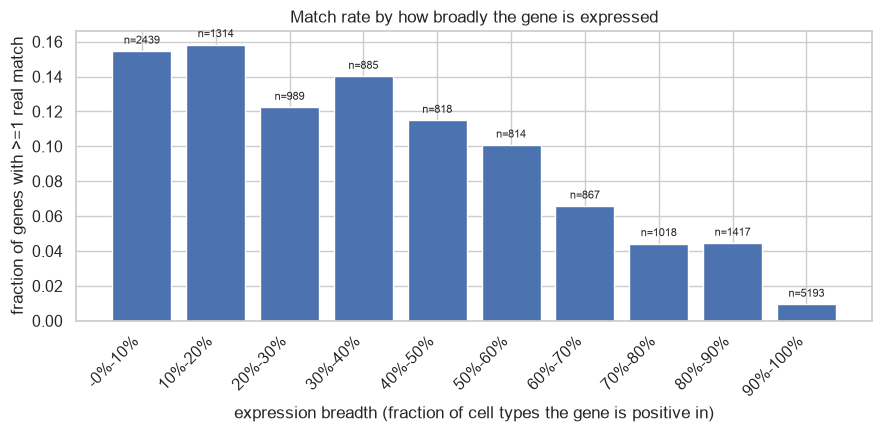

In [9]:
gene_props["breadth_bin"] = pd.cut(gene_props["breadth"], bins=[i / 10 for i in range(11)], include_lowest=True)
rate_by_breadth = gene_props.groupby("breadth_bin", observed=True)["got_a_match"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(range(len(rate_by_breadth)), rate_by_breadth["mean"], color=COLORS["volume"])
for i, (bar, n) in enumerate(zip(bars, rate_by_breadth["count"])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"n={n}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(rate_by_breadth)))
ax.set_xticklabels([f"{iv.left:.0%}-{iv.right:.0%}" for iv in rate_by_breadth.index], rotation=45, ha="right")
ax.set_xlabel("expression breadth (fraction of cell types the gene is positive in)")
ax.set_ylabel("fraction of genes with >=1 real match")
ax.set_title("Match rate by how broadly the gene is expressed")
fig.tight_layout()
save(fig, "06_breadth_vs_match")
plt.show()

## 7. How specific are the predicted terms, by outcome?

**Information content (IC)** measures how rare/specific a GO term is among annotated human genes --
`IC = -ln(fraction of genes carrying it)`. A generic term like "biological_process" has IC ~0; a narrow,
specific term has a high IC. If `exact` matches cluster at LOW IC, the method's wins are cheap, generic
hits; if they cluster at HIGH IC, they are genuinely specific, informative predictions.

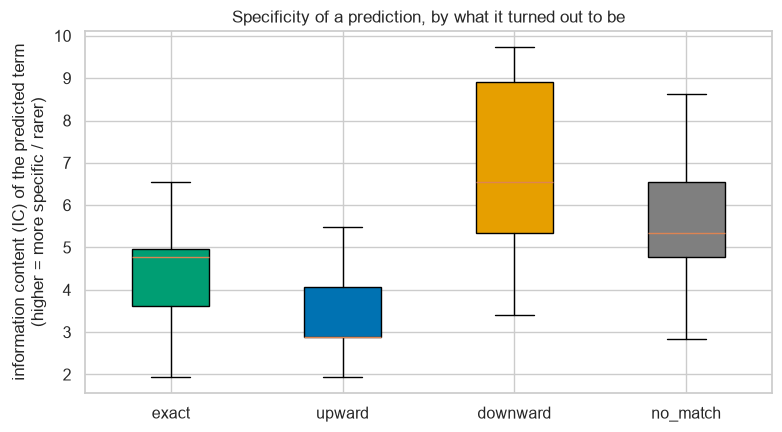

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [term_props.loc[term_props["kind"] == k, "ic"] for k in ORDER]
bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, showfliers=False)
for patch, k in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLORS[k])
ax.set_ylabel("information content (IC) of the predicted term\n(higher = more specific / rarer)")
ax.set_title("Specificity of a prediction, by what it turned out to be")
fig.tight_layout()
save(fig, "07_ic_by_outcome")
plt.show()

## 8. Is match rate just tracking how much a gene is annotated?

A gene with 40 known true terms has far more "targets" to accidentally land a match on than one with 3,
independent of whether arm 1 is finding anything real. **Left**: raw match rate vs. annotation richness --
expected to rise simply from having more targets. **Right**: match rate *normalized per true term
available* (`n_matches / n_direct_terms`) -- if this is flat or declining, the raw rise on the left is
explained by opportunity alone, not a genuinely better hit rate for well-annotated genes. This also speaks
to this project's earlier §L5 finding that annotation richness tracks how well-studied a gene is, not its
biological importance.

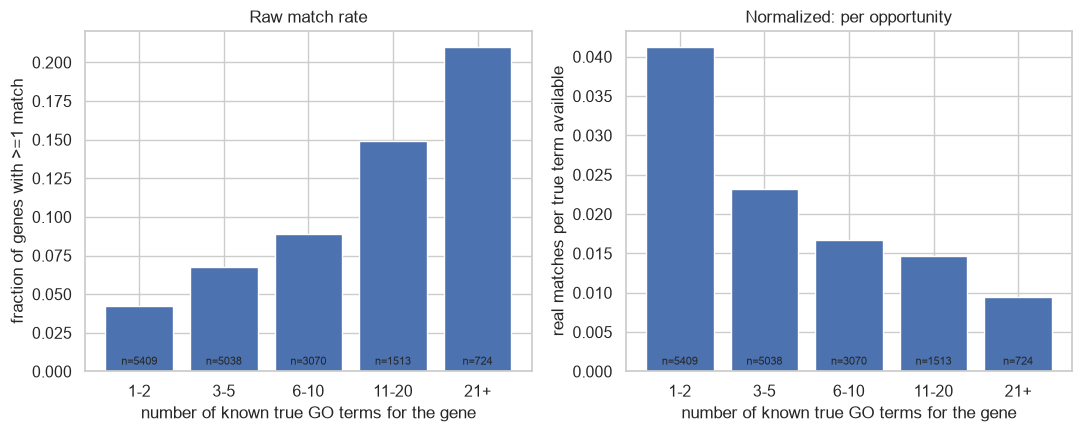

In [11]:
bins = [0, 3, 6, 11, 21, gene_props["n_direct_terms"].max() + 1]
labels = ["1-2", "3-5", "6-10", "11-20", "21+"]
gene_props["richness_bin"] = pd.cut(gene_props["n_direct_terms"], bins=bins, labels=labels, right=False)
gene_props["n_real_matches"] = gene_props[["n_exact", "n_upward", "n_downward"]].sum(axis=1)
gene_props["matches_per_true_term"] = gene_props["n_real_matches"] / gene_props["n_direct_terms"]

by_rich = gene_props.groupby("richness_bin", observed=True).agg(
    match_rate=("got_a_match", "mean"), per_term=("matches_per_true_term", "mean"), n=("gene_id", "count"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.bar(by_rich.index.astype(str), by_rich["match_rate"], color=COLORS["volume"])
ax1.set_xlabel("number of known true GO terms for the gene"); ax1.set_ylabel("fraction of genes with >=1 match")
ax1.set_title("Raw match rate")
ax2.bar(by_rich.index.astype(str), by_rich["per_term"], color=COLORS["volume"])
ax2.set_xlabel("number of known true GO terms for the gene"); ax2.set_ylabel("real matches per true term available")
ax2.set_title("Normalized: per opportunity")
for ax in (ax1, ax2):
    for i, n in enumerate(by_rich["n"]):
        ax.text(i, ax.get_ylim()[1] * 0.02, f"n={n}", ha="center", fontsize=8)
fig.tight_layout()
save(fig, "08_annotation_richness")
plt.show()

## 9. Term size (statistical power) by outcome

`term_size` (K) is how many cell types in the background carry a candidate term -- a small K means a
single hit or miss can swing significance (see the arm-1 README's `--min-term-size` discussion). If real
matches cluster on small-K terms, the "win" may be a low-power coincidence rather than a robust signal.

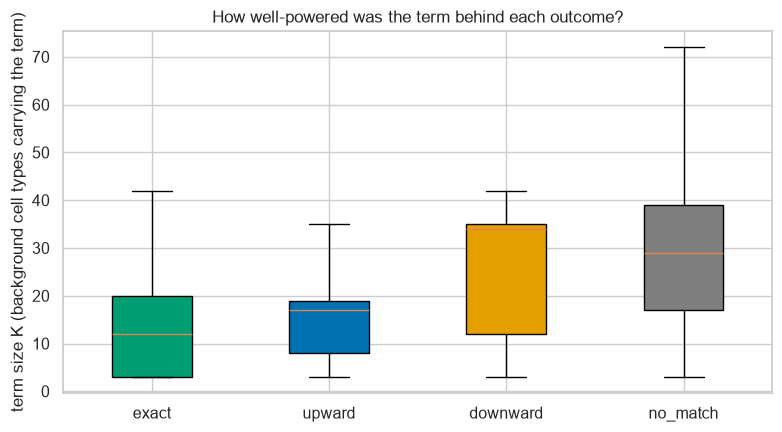

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [term_props.loc[term_props["kind"] == k, "term_size"] for k in ORDER]
bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, showfliers=False)
for patch, k in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLORS[k])
ax.set_ylabel("term size K (background cell types carrying the term)")
ax.set_title("How well-powered was the term behind each outcome?")
fig.tight_layout()
save(fig, "09_term_size_by_outcome")
plt.show()

## 10. Calibration — does arm 1's own ranking mean anything?

Among a gene's significant predictions, the one with the smallest p-value (g:SCS) is ranked first. If that
top-ranked term is no more likely to be a real match than the 3rd or 4th one, arm 1's significance ordering
carries no information about which of its own predictions to trust -- a distinct finding from "does it find
anything at all".

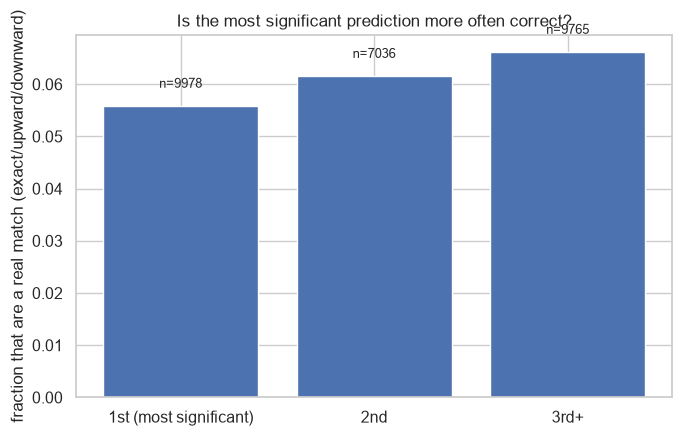

In [13]:
term_props["rank_bucket"] = term_props["rank"].clip(upper=3).map({1: "1st (most significant)", 2: "2nd", 3: "3rd+"})
term_props["is_real_match"] = term_props["kind"] != "no_match"
by_rank = term_props.groupby("rank_bucket", observed=True)["is_real_match"].agg(["mean", "count"])
by_rank = by_rank.reindex(["1st (most significant)", "2nd", "3rd+"])

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(by_rank.index, by_rank["mean"], color=COLORS["volume"])
for bar, n in zip(bars, by_rank["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"n={n}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("fraction that are a real match (exact/upward/downward)")
ax.set_title("Is the most significant prediction more often correct?")
fig.tight_layout()
save(fig, "10_calibration_by_rank")
plt.show()

## 11. Which vocabulary terms account for the matches?

A Pareto view of the 52-term candidate vocabulary: if a handful of terms account for most matches, the
method's apparent success is concentrated in a few well-annotated biological domains rather than spread
across general biology.

/var/folders/6n/xwm6w0015417z1bwqghfk2_c0000gn/T/ipykernel_61615/2153285786.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


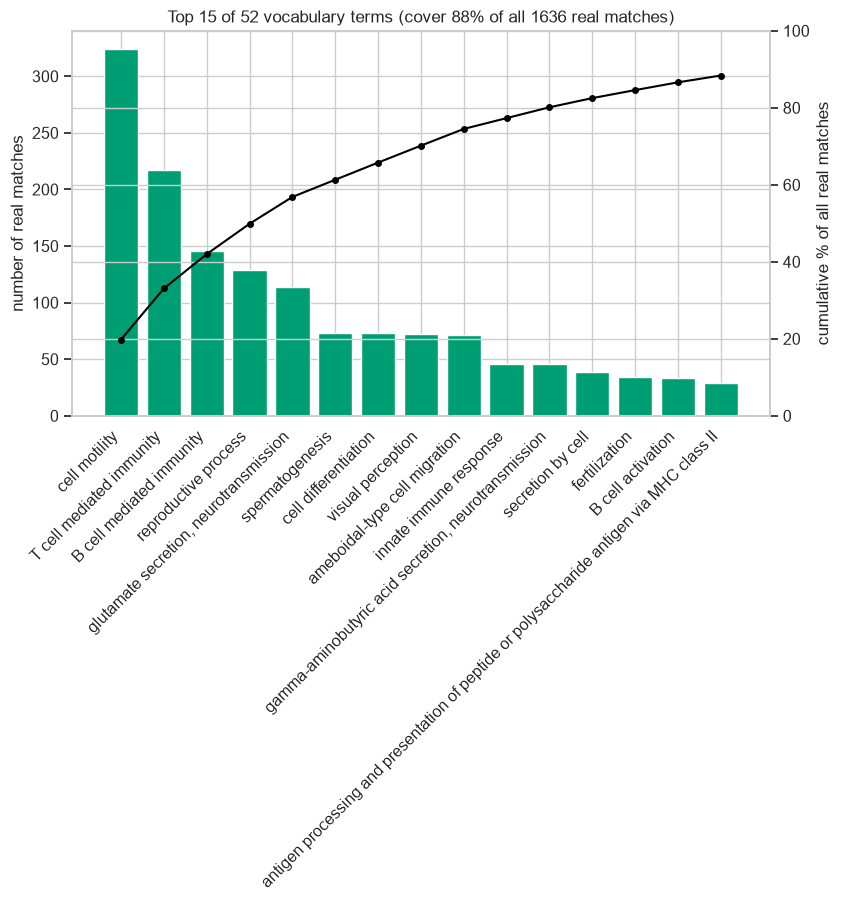

In [14]:
wins = term_props[term_props["kind"] != "no_match"]
top = wins["label"].value_counts().head(15)
cum_pct = (top.cumsum() / len(wins) * 100)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(len(top)), top.values, color=COLORS["exact"])
ax1.set_xticks(range(len(top))); ax1.set_xticklabels(top.index, rotation=45, ha="right")
ax1.set_ylabel("number of real matches"); ax1.set_xlabel("")
ax2 = ax1.twinx()
ax2.plot(range(len(top)), cum_pct.values, color="black", marker="o", markersize=4)
ax2.set_ylabel("cumulative % of all real matches"); ax2.set_ylim(0, 100)
ax1.set_title(f"Top 15 of 52 vocabulary terms (cover {cum_pct.iloc[-1]:.0f}% of all {len(wins)} real matches)")
fig.tight_layout()
save(fig, "11_pareto_terms")
plt.show()

## 12. Batch/tissue artifact: matched vs. unmatched genes

`frac_allornothing_tissues` is a pre-existing diagnostic (`core/enrichment.tissue_homogeneity`): the share
of a gene's tissues where it is almost entirely positive or almost entirely negative -- usually a sign of
which study profiled that tissue and how deeply, not gene biology (see `approaches/README.md`, §L9/§L11).
If matched genes score similarly to unmatched ones here, the matches are not simply riding a batch
artifact.

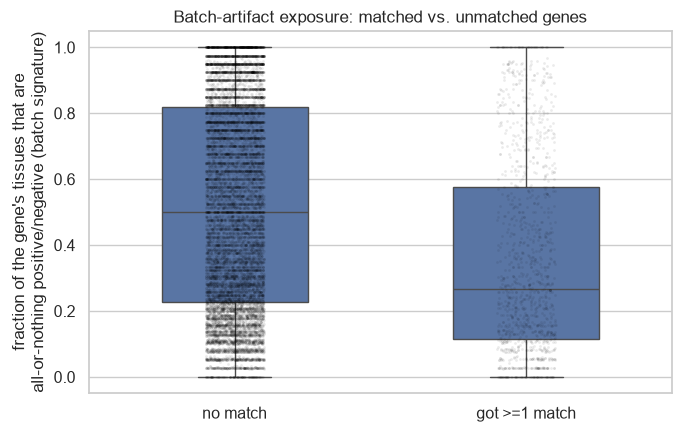

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = gene_props.assign(group=gene_props["got_a_match"].map({True: "got >=1 match", False: "no match"}))
sns.boxplot(data=plot_df, x="group", y="frac_allornothing_tissues", order=["no match", "got >=1 match"],
            color=COLORS["volume"], width=0.5, ax=ax, showfliers=False)
sns.stripplot(data=plot_df, x="group", y="frac_allornothing_tissues", order=["no match", "got >=1 match"],
             color="black", alpha=0.08, size=2, ax=ax)
ax.set_ylabel("fraction of the gene's tissues that are\nall-or-nothing positive/negative (batch signature)")
ax.set_xlabel("")
ax.set_title("Batch-artifact exposure: matched vs. unmatched genes")
fig.tight_layout()
save(fig, "12_batch_artifact")
plt.show()

## 13. Are the matches concentrated in a few gene families?

HGNC groups genes into families (e.g. "Opsins", "Immunoglobulin like domain containing"). If matched genes
cluster heavily into a handful of families, the method's apparent reach is narrower than "7.7% of genes"
suggests -- it may really be "most members of a few families this vocabulary already encodes well".

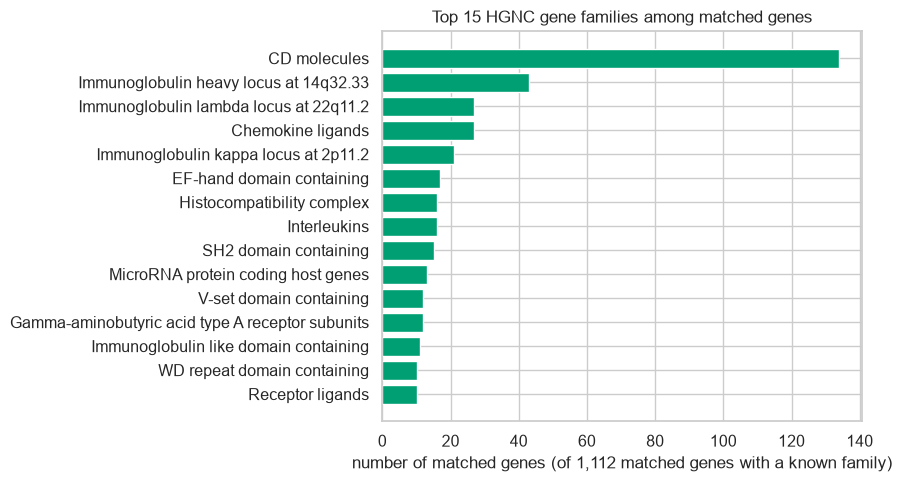

top 5 families account for 22.7% of all matched genes with a known family


In [16]:
matched = gene_props[gene_props["got_a_match"] & gene_props["gene_group"].notna()]
top_fam = matched["gene_group"].value_counts().head(15)
background_rate = gene_props[gene_props["gene_group"].notna()]["gene_group"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_fam.index[::-1], top_fam.values[::-1], color=COLORS["exact"])
ax.set_xlabel(f"number of matched genes (of {len(matched):,} matched genes with a known family)")
ax.set_title("Top 15 HGNC gene families among matched genes")
fig.tight_layout()
save(fig, "13_gene_families")
plt.show()

print(f"top 5 families account for {top_fam.head(5).sum() / len(matched):.1%} of all matched genes with a known family")

## 14. How strong is the evidence behind the matched truth term?

For every real match, the gene's own true term it matched against has GOA evidence code(s) --
**experimental** (directly measured: IDA, IMP, IGI, IEP, ...) or **non-experimental** (inferred: IBA
phylogeny, ISS sequence similarity, TAS/NAS author statement, ...). A match resting on experimental
evidence is a more trustworthy "win" than one resting only on an inferred annotation.

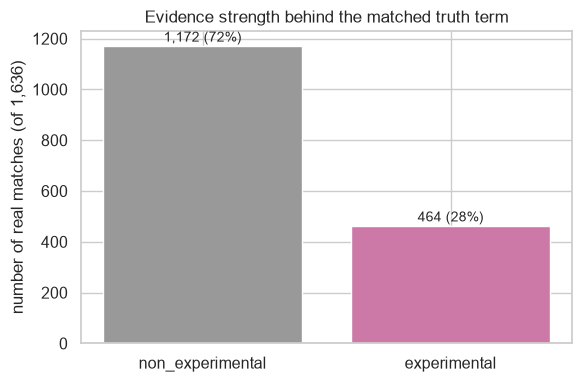

In [17]:
ev = wins.dropna(subset=["matched_evidence_experimental"])
counts = ev["matched_evidence_experimental"].map({True: "experimental", False: "non_experimental"}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[COLORS[k] for k in counts.index])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(ev) * 0.01,
            f"{v:,} ({v/len(ev):.0%})", ha="center", fontsize=10)
ax.set_ylabel(f"number of real matches (of {len(ev):,})")
ax.set_title("Evidence strength behind the matched truth term")
fig.tight_layout()
save(fig, "14_evidence_strength")
plt.show()

## Part 2 summary

- **Expression breadth is the strongest single predictor** (Plot 6): match rate falls from ~15% for
  genes expressed in under 20% of cell types to under 1% for genes expressed in over 90% -- roughly a
  17x difference, in the direction expression-breadth theory predicts.
- **Matches are not cheap, generic hits** (Plots 7, 9): exact matches have moderate-to-high specificity
  (median IC ~4.8) and skew toward *smaller*, more specific terms (median K~12) than `no_match` terms
  (median K~29, IC~5.3 -- about as specific, just wrong). The method is not winning by picking large,
  easy, low-power terms.
- **Annotation richness inflates the raw count, but not the per-opportunity rate** (Plot 8): raw match
  rate rises from 4% to 21% with more known true terms, exactly as the "more targets, more chances"
  confound predicts -- but the *normalized* rate (matches per true term available) actually falls, from
  0.041 to 0.009. Sparsely-annotated genes are not being short-changed; if anything each of their few
  true terms is more likely to land a hit.
- **Arm 1's own confidence ranking carries no useful signal** (Plot 10): the single most significant
  prediction is correct only 5.6% of the time, *less* often than the 3rd-or-later one (6.6%). A user
  reading only the top hit per gene would do no better -- slightly worse -- than reading further down
  the list.
- **The wins are heavily concentrated** (Plots 11, 13): 15 of the 52 candidate terms account for 88% of
  every real match, and the single HGNC family "CD molecules" alone outweighs any other family, with
  immune-related families (3 immunoglobulin loci, chemokines, MHC, interleukins) dominating the rest.
  "7.7% of genes get a match" over-states how broadly this generalizes -- it is close to "most of a few
  already-well-annotated, mostly-immune gene families."
- **Matches are not a batch artifact** (Plot 12): matched genes have *lower* tissue batch-signature
  exposure (median 0.27) than unmatched genes (median 0.50) -- reassuring, but also means batch effects
  are not the explanation for why the match rate is so low overall.
- **Most wins rest on inferred, not directly measured, evidence** (Plot 14): 72% of matched truth terms
  are backed only by non-experimental GOA evidence (phylogeny, sequence similarity, author statement);
  28% have direct experimental support. The GNAT1/CSF1R examples highlighted in Part 1 are the stronger
  end of this distribution, not the typical case.

**Taken together:** arm 1 works best for narrowly-expressed genes in a handful of well-annotated,
largely-immune gene families, producing specific (not generic) predictions when it does hit -- but it
cannot tell you, from its own output, which of its predictions to trust, and most of its successes rest on
inferred rather than directly measured biology.